In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
np.random.seed(42)

n = 400

# Simulate 3 natural customer groups so clustering has something real to find
# Group 1: low spenders, infrequent
group1 = pd.DataFrame({
    'AnnualIncome': np.random.normal(25000, 5000, n//4),
    'PurchaseFrequency': np.random.normal(5, 2, n//4),
    'AvgSpendPerPurchase': np.random.normal(20, 5, n//4)
})

# Group 2: mid income, frequent small purchases
group2 = pd.DataFrame({
    'AnnualIncome': np.random.normal(55000, 8000, n//4),
    'PurchaseFrequency': np.random.normal(20, 4, n//4),
    'AvgSpendPerPurchase': np.random.normal(40, 8, n//4)
})

# Group 3: high income, big-ticket rare purchases
group3 = pd.DataFrame({
    'AnnualIncome': np.random.normal(90000, 10000, n//4),
    'PurchaseFrequency': np.random.normal(8, 3, n//4),
    'AvgSpendPerPurchase': np.random.normal(150, 30, n//4)
})

# Group 4: high income, frequent big purchases (VIP customers)
group4 = pd.DataFrame({
    'AnnualIncome': np.random.normal(95000, 8000, n//4),
    'PurchaseFrequency': np.random.normal(25, 5, n//4),
    'AvgSpendPerPurchase': np.random.normal(180, 25, n//4)
})

df = pd.concat([group1, group2, group3, group4], ignore_index=True)

# Clip negative values (can't have negative income/frequency)
df = df.clip(lower=0)

# Add a CustomerID column
df.insert(0, 'CustomerID', range(1, len(df)+1))

df.head(10)

,CustomerID,AnnualIncome,PurchaseFrequency,AvgSpendPerPurchase
0,1,27483.570765,2.169259,21.788937
1,2,24308.678494,4.158709,22.803923
2,3,28238.442691,4.314571,25.415256
3,4,32615.149282,3.395445,25.269010
4,5,23829.233126,4.677429,13.111653
5,6,23829.315215,5.808102,15.310875
6,7,32896.064078,8.772372,22.575176
7,8,28837.173646,5.349156,22.568930
8,9,22652.628070,5.515101,22.575238
9,10,27712.800218,4.851108,39.263657


In [ ]:
print(df.info())
print("\nStatistics:\n", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           400 non-null    int64  
 1   AnnualIncome         400 non-null    float64
 2   PurchaseFrequency    400 non-null    float64
 3   AvgSpendPerPurchase  400 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 12.6 KB
None

Statistics:
        CustomerID   AnnualIncome  PurchaseFrequency  AvgSpendPerPurchase
count  400.000000     400.000000         400.000000           400.000000
mean   200.500000   66449.814403          14.650745            99.734700
std    115.614301   29658.508599           9.226860            73.838961
min      1.000000   11901.274480           1.162458             3.793663
25%    100.750000   37071.973385           5.960625            27.749155
50%    200.500000   70874.232460          13.137920            81.346610
75%    300.2500

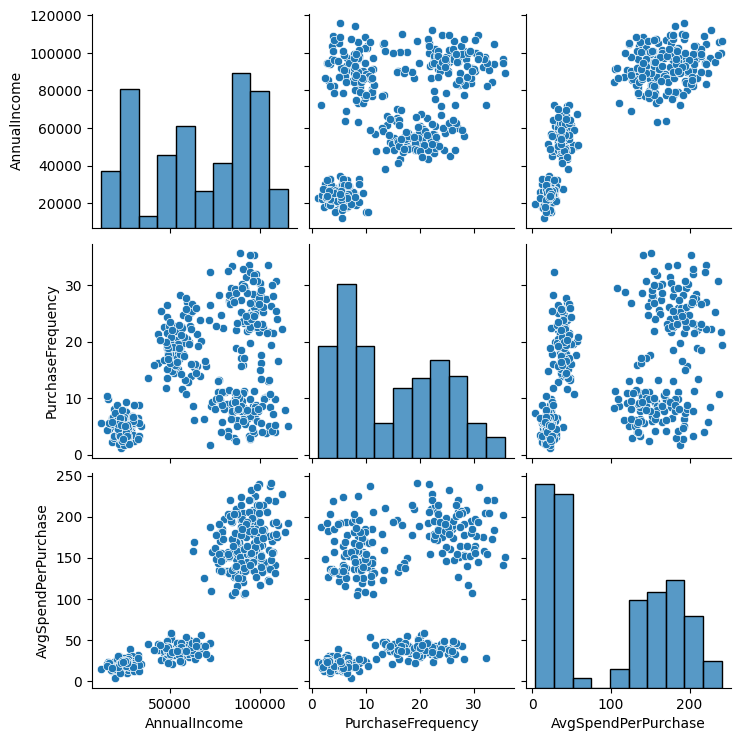

In [ ]:
sns.pairplot(df.drop('CustomerID', axis=1))
plt.savefig('pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
features = df[['AnnualIncome', 'PurchaseFrequency', 'AvgSpendPerPurchase']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print(scaled_features[:5])

[[-1.31547555 -1.35442808 -1.05694036]
 [-1.42265789 -1.13854289 -1.04317721]
 [-1.28999156 -1.12162958 -1.00776767]
 [-1.14223673 -1.22136845 -1.00975075]
 [-1.43884366 -1.0822541  -1.17460386]]


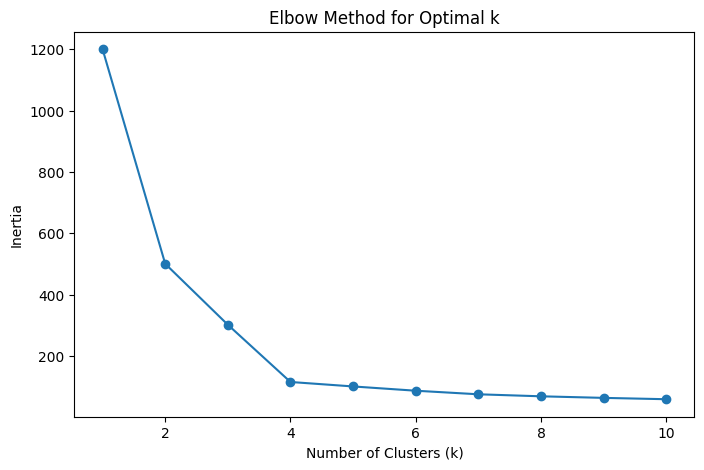

In [ ]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.savefig('elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
optimal_k = 4  # based on the elbow graph — change if yours shows a different elbow

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_features)

df['Cluster'] = cluster_labels
df.head(10)

,CustomerID,AnnualIncome,PurchaseFrequency,AvgSpendPerPurchase,Cluster
0,1,27483.570765,2.169259,21.788937,3
1,2,24308.678494,4.158709,22.803923,3
2,3,28238.442691,4.314571,25.415256,3
3,4,32615.149282,3.395445,25.269010,3
4,5,23829.233126,4.677429,13.111653,3
5,6,23829.315215,5.808102,15.310875,3
6,7,32896.064078,8.772372,22.575176,3
7,8,28837.173646,5.349156,22.568930,3
8,9,22652.628070,5.515101,22.575238,3
9,10,27712.800218,4.851108,39.263657,3


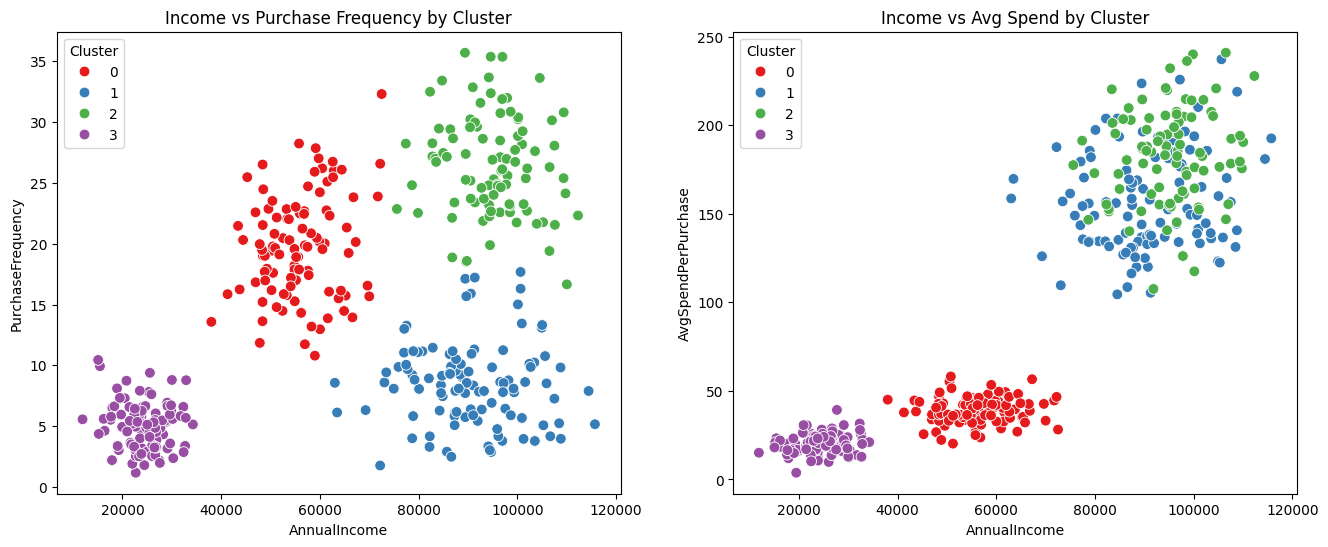

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Income vs Purchase Frequency
sns.scatterplot(data=df, x='AnnualIncome', y='PurchaseFrequency', hue='Cluster', palette='Set1', s=60, ax=axes[0])
axes[0].set_title('Income vs Purchase Frequency by Cluster')

# Income vs Avg Spend
sns.scatterplot(data=df, x='AnnualIncome', y='AvgSpendPerPurchase', hue='Cluster', palette='Set1', s=60, ax=axes[1])
axes[1].set_title('Income vs Avg Spend by Cluster')

plt.savefig('clusters.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
cluster_summary = df.groupby('Cluster')[['AnnualIncome', 'PurchaseFrequency', 'AvgSpendPerPurchase']].mean().round(2)
cluster_summary['CustomerCount'] = df['Cluster'].value_counts().sort_index()
print(cluster_summary)

         AnnualIncome  PurchaseFrequency  AvgSpendPerPurchase  CustomerCount
Cluster                                                                     
0            55854.72              19.78                39.08            100
1            90679.61               8.42               157.42            106
2            95046.15              26.45               183.69             94
3            24480.77               5.04                20.32            100


In [ ]:
new_customer = pd.DataFrame({
    'AnnualIncome': [60000],
    'PurchaseFrequency': [18],
    'AvgSpendPerPurchase': [45]
})

new_customer_scaled = scaler.transform(new_customer)
predicted_cluster = kmeans.predict(new_customer_scaled)
print(f"This customer belongs to Cluster: {predicted_cluster[0]}")

This customer belongs to Cluster: 0


In [ ]:
df.to_csv('customer_segments.csv', index=False)

from google.colab import files
files.download('customer_segments.csv')
files.download('pairplot.png')
files.download('elbow_method.png')
files.download('clusters.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>